In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *
import matplotlib.pyplot as plt

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, True, device)

x += torch.randn_like(x) * dx * 0.1

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [5]:
adjacency = radiusSearchCompactHashMap(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        domain.periodic, domain,
        mode, hashMapLength
)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' (block_dim=256) ...
            continue  # No particles in this cell

        dist_sq += dx * dx

                    count += 1

                    count += 1

            continue  # No particles in this cell

                    edge_index += 1

                    edge_index += 1

            hashValue += wp.uint32(cellIndex[d] * primes[d])

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompati

In [6]:

import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation

particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))

positions_t = referencePositions.clone()
simulationState = BasicState(
    positions = positions_t,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(referencePositions),
    kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
)

# neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)

state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, True, True, False)

neighborhood = state.get('noghost')


In [7]:
from sphWarpCore.ops import sphOperation_warp

In [8]:
from sphWarpCore.enumTypes import *

[Kernel.add_overload] Creating new overload for computeSPHDensity_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i4_a1i4_i4_a1i4_a1i4_a1f4
Module sphWarpCore.operations.wp_density 414a5a1 load on device 'cuda:0' (block_dim=256) ...
        out += referenceMasses[j] * sphKernel(xi, referencePositions[j], hi, referenceSupports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax) 

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp___main___63bdc91.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

"wp_sphWarpCore.operations.wp_density_414a5a1.cu": using precompiled heade

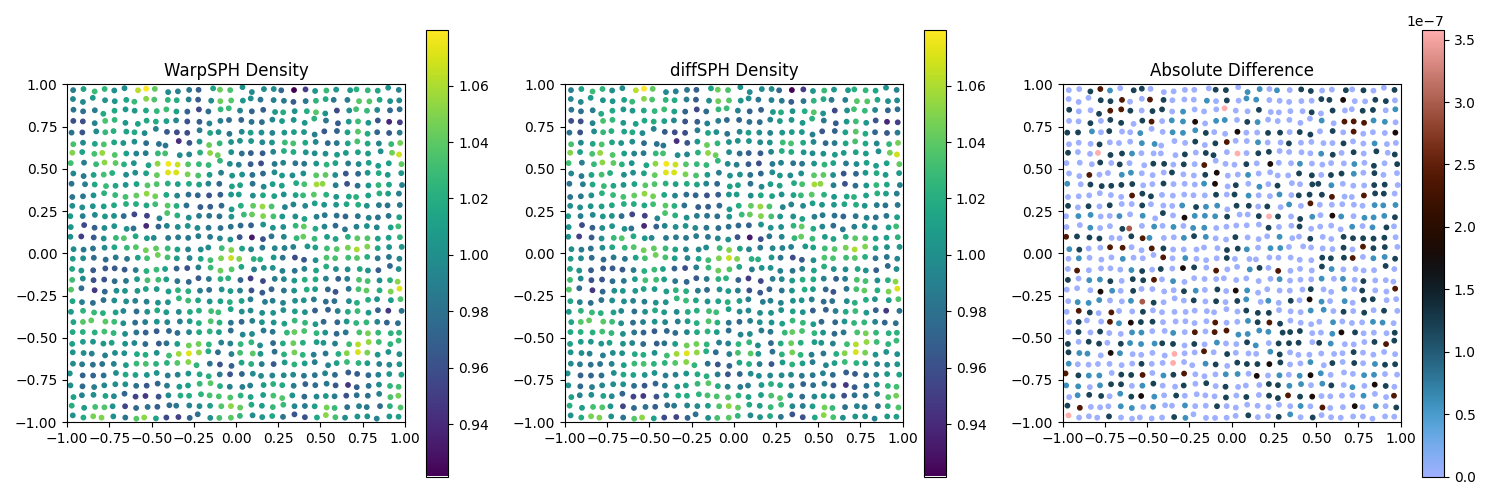

In [9]:
densities_warp = sphOperation_warp(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        queryMasses, referenceMasses,
        None, None, 
        None, None, 
        domain, adjacency,
        operation=WarpOperation.Density,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
)
queryDensities = densities_warp
referenceDensities = densities_warp

densities_diffSPH = SPHOperation(
        simulationState,
        quantity = None,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Density,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
        )
simulationState.densities = densities_diffSPH


fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = densities_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Density")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = densities_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Density")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(densities_warp - densities_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()


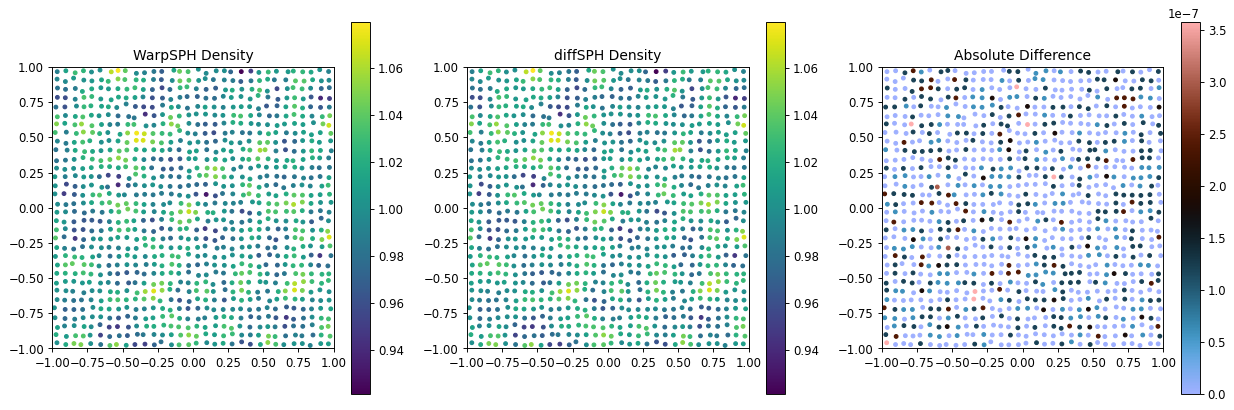

In [10]:
display(fig)

In [11]:

from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt

from diffSPH.enums import SupportScheme as DiffSPHSupportScheme, KernelType as DiffSPHKernelType, KernelCorrectionScheme


In [12]:

simulationState.omega = torch.ones_like(simulationState.masses)
simulationState.apparentArea = computeCRKVolume(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.Gather, {})
kernelMoments = computeGeometricMoments(simulationState, KernelType.Wendland2, neighborhood, DiffSPHSupportScheme.SuperSymmetric, {})       
simulationState.numNeighbors = adjacency.numNeighbors
simulationState.A, simulationState.B, simulationState.gradA, simulationState.gradB = computeCRKTerms(kernelMoments, simulationState.numNeighbors, simulationState.supports)
# simulationState.A, simulationState.B = None, None
simulationState.densities = computeCRKDensity(simulationState, KernelType.Wendland2, neighborhood, SupportScheme.SuperSymmetric, {})
f = 2 + queryPositions[:,0] * 20

In [13]:
from diffSPH.neighborhood import evalKernel, evalKernelGradient
from diffSPH.operations import SPHOperation, scatter_sum

def correctedKernel(A, B, kernelValues, supportScheme: SupportScheme = SupportScheme.SuperSymmetric, xji: bool = False):

    print(f'A: shape: {A.shape}, dtype: {A.dtype}, device: {A.device}')
    print(f'B: shape: {B.shape}, dtype: {B.dtype}, device: {B.device}')
    print(f'kernelValues.x_ij: shape: {kernelValues.x_ij.shape}, dtype: {kernelValues.x_ij.dtype}, device: {kernelValues.x_ij.device}')
    # print(f'kernelValues.W_ij: shape: {kernelValues.W_ij.shape}, dtype: {kernelValues.W_ij.dtype}, device: {kernelValues.W_ij.device}')

    fac = -1 if xji else 1
    prod = torch.einsum('...i, ...i -> ...', B, fac * kernelValues.x_ij)
    W_ij = evalKernel(kernelValues, supportScheme=supportScheme, combined=True)
    return A * (1 + prod) * W_ij

In [14]:
# simulationState.A = A
# simulationState.B = B
f_interp_CRK = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation= Operation.Interpolate,
        supportScheme = DiffSPHSupportScheme.SuperSymmetric,
        correctionTerms= [KernelCorrectionScheme.CRKSPH],
        positiveDivergence=False,
        useApparentArea=True
        )

In [15]:
j = neighborhood[0].col
i = neighborhood[0].row

fj = f[j]
Vj = simulationState.apparentArea[j]

W_ij = correctedKernel(simulationState.A[i], simulationState.B[i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)

Term = Vj * W_ij * fj
result = scatter_sum(Term, i, dim = 0, dim_size = simulationState.positions.shape[0])

A: shape: torch.Size([49494]), dtype: torch.float32, device: cuda:0
B: shape: torch.Size([49494, 2]), dtype: torch.float32, device: cuda:0
kernelValues.x_ij: shape: torch.Size([49494, 2]), dtype: torch.float32, device: cuda:0


In [16]:
import warp as wp
from warp.types import vector, matrix
# from wp_tensor import tensor
from typing import Any, Optional
import torch
from sphWarpCore.utils.wp_autograd import *
from sphWarpCore.radiusSearch.radius_util import convertModeToUint

from sphWarpCore.radiusSearch.radius_util import AdjacencyList, AdjacencyListWarp, DomainDescription, PointCloud
from sphWarpCore.mathutil.wp_math import *
from sphWarpCore.kernels.wp_kernel import *
from torch.profiler import profile, record_function, ProfilerActivity
from sphWarpCore.utils.wp_util import checkDirectionality_i, checkDirectionality_j


@wp.func
def computeSPHInterpolation_Func_CRK(
    xi: vector(dtype = wp.float32, length=Any), hi : wp.float32, mi: wp.float32, rhoi: wp.float32, # type: ignore
    positions : wp.array(dtype=vector(length=Any, dtype = wp.float32)), supports : wp.array(dtype = wp.float32), masses: wp.array(dtype = wp.float32), densities: wp.array(dtype = wp.float32), # type: ignore
    
    periodicity : wp.array(dtype = wp.bool), domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), # type: ignore
    mode_uint: wp.uint32, kernel_int: wp.int32,
    
    neighborList: wp.array(dtype = wp.int64), # type: ignore
    neighborOffset : wp.int32, numNeighs: wp.int32, preScatteredQuantities: wp.bool,
    
    fi: Any,
    fieldValues: wp.array(dtype = Any), # type: ignore
    opInt: wp.int32, referenceKinds : wp.array(dtype = wp.int32), # type: ignore
    crkCorrection: wp.bool, Ai: wp.float32, Bi: vector(length=Any, dtype=wp.float32), # type: ignore
    useApparentVolume: wp.bool, referenceVolumes: wp.array(dtype = wp.float32) # type: ignore
):
    f_interpolated = type(fi)(0.0)
    
    for neighborIndex in range(numNeighs):
        jj = neighborOffset + neighborIndex
        j = wp.int32(neighborList[jj])
        if opInt != 0:
            if not checkDirectionality_j(referenceKinds[j], opInt):
                continue

        fv = fieldValues[jj] if preScatteredQuantities else fieldValues[j]

        vj = masses[j] / densities[j] if not useApparentVolume else referenceVolumes[j]
        w_ij = sphKernel(xi, positions[j], hi, supports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)
        if crkCorrection:
            xij = computeDistanceVec(xi, positions[j], periodicity, domainMin, domainMax)
            prod = Ai * (1.0 + wp.dot(Bi, xij)) * w_ij
            w_ij = prod

        f_interpolated += fv * vj * w_ij
            
    return f_interpolated



In [17]:

@wp.kernel
def computeSPHInterpolation_Kernel_CRK(
    queryPositions : wp.array(dtype = vector(length=Any, dtype=wp.float32)), referencePositions : wp.array(dtype=vector(length=Any, dtype=wp.float32)), # type: ignore
    querySupports : wp.array(dtype = wp.float32), referenceSupports : wp.array(dtype = wp.float32), # type: ignore
    queryMasses: wp.array(dtype = wp.float32), referenceMasses: wp.array(dtype = wp.float32),  # type: ignore
    queryDensities: wp.array(dtype = wp.float32), referenceDensities: wp.array(dtype = wp.float32), # type: ignore
    queryValues: wp.array(dtype = Any), referenceValues: wp.array(dtype = Any), # type: ignore
    
    domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), periodicity : wp.array(dtype = wp.bool), # type: ignore
    
    mode_uint: wp.uint32, kernel_int : wp.int32,
    neighborList: wp.array(dtype = wp.int64), neighborListRowOffsets: wp.array(dtype = wp.int32), numNeighbors: wp.array(dtype = wp.int32), preScatteredQuantities: wp.bool,  # type: ignore

    opInt: wp.int32, queryKinds : wp.array(dtype = wp.int32), referenceKinds : wp.array(dtype = wp.int32), # type: ignore
    
    crkCorrection: bool, crk_A: wp.array(dtype = wp.float32), crk_B: wp.array(dtype = vector(length=Any, dtype=wp.float32)), # type: ignore
    useApparentVolume: bool, queryVolumes: wp.array(dtype = wp.float32), referenceVolumes: wp.array(dtype = wp.float32), # type: ignore
    
    outputValues : wp.array(dtype = Any) # type: ignore
):                                                                                    
    i = wp.tid()
    if i >= queryPositions.shape[0]:
        return
    
    if opInt != 0:
        if not checkDirectionality_i(queryKinds[i], opInt):
            return
        
    xi = queryPositions[i]
    hi = querySupports[i]
    mi = queryMasses[i]
    rhoi = queryDensities[i]
    fi = queryValues[i]
    
    neighborOffset = neighborListRowOffsets[i]
    numNeighs = numNeighbors[i]

    Ai = crk_A[i] if crkCorrection else type(crk_A[0])(0.0)
    Bi = crk_B[i] if crkCorrection else type(crk_B[0])(0.0)
    
    outputValues[i] = computeSPHInterpolation_Func_CRK(
        xi, hi, mi, rhoi,
        referencePositions, referenceSupports, referenceMasses, referenceDensities,
        periodicity, domainMin, domainMax, mode_uint, kernel_int,
        neighborList, neighborOffset, wp.int32(numNeighs), preScatteredQuantities,
        fi, referenceValues, opInt, referenceKinds,
        crkCorrection, Ai, Bi,
        useApparentVolume, referenceVolumes

    )
    

In [18]:


from sphWarpCore.enumTypes import *
from sphWarpCore.operations.wp_interpolate import computeSPHInterpolation_Kernel

def computeSPHInterpolant_warpBackend_CRK(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    queryValues, referenceValues,
    queryKinds, referenceKinds,
    domain: DomainDescription,
    mode: SupportScheme,
    kernel: KernelFunctions,    
    operationMode: OperationDirection,
    adjacency,
    crkCorrection: bool,
    useApparentVolume: bool, queryVolumes: torch.Tensor, referenceVolumes: torch.Tensor,
    crk_A: torch.Tensor, crk_B: torch.Tensor,
    scatteredQuantities: Optional[torch.Tensor] = None, 

):
    with record_function("warpSPH[Interpolation]"):
        with record_function("warpSPH[Interpolation] - Preprocessing"):
            domainMin = domain.min
            domainMax = domain.max
            periodicity = domain.periodic

            preScatteredQuantities = False
            if queryValues is None and referenceValues is None:
                if scatteredQuantities is None:
                    raise ValueError("If queryValues and referenceValues are not provided, then pre-scattered quantities must be provided for the interpolation computation.")
                preScatteredQuantities = True
                qV = scatteredQuantities
                rV = scatteredQuantities
            else:
                qV = queryValues
                rV = referenceValues

            # Warp kernels only support rank-1 (vector) and rank-2 (matrix) field types.
            # For higher-rank inputs (e.g. shape (n, p, m, d)) we flatten the field
            # dimensions to a single vector dimension, interpolate, then restore the
            # original shape.  Rank <= 3 inputs (scalar / vector / matrix per particle)
            # pass through unchanged.
            field_shape = qV.shape[1:]   # all dims after the particle batch dim
            needs_flatten = qV.dim() > 3
            if needs_flatten:
                flat_len = qV[0].numel()
                qV = qV.reshape(qV.shape[0], flat_len).contiguous()
                rV = rV.reshape(rV.shape[0], flat_len).contiguous()

            
            modeUint = wp.uint32(mode.value)
            kernelInt = wp.int32(kernel.value)
            outputShape = qV.shape[0]
            opInt = wp.int32(operationMode.value)
            
            wpValues = castTorchToWarpAsBuiltins(qV)
        with record_function("warpSPH[Interpolation] - Kernel Launch"):

            warp_interpolation = warpWrapper(
                launch_kernel, computeSPHInterpolation_Kernel_CRK, outputShape, wpValues.dtype, 
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                qV, rV,
                
                domainMin, domainMax, periodicity,
                modeUint,
                kernelInt,
                
                adjacency.j, adjacency.edgeOffsets, adjacency.numNeighbors, wp.bool(preScatteredQuantities),
                opInt, queryKinds, referenceKinds,
                crkCorrection, crk_A, crk_B,
                useApparentVolume, queryVolumes, referenceVolumes,
            )

            if needs_flatten:
                warp_interpolation = warp_interpolation.reshape(
                    warp_interpolation.shape[0], *field_shape
                )

    return warp_interpolation

In [19]:
warp_crk_interpolation = computeSPHInterpolant_warpBackend_CRK(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    f, f,
    torch.zeros(size = (queryPositions.shape[0],), device=queryPositions.device, dtype = torch.int32), torch.zeros(size = (referencePositions.shape[0],), device=referencePositions.device, dtype = torch.int32),
    domain, 
    kernel = KernelFunctions.Wendland2, mode = SupportScheme.SuperSymmetric,
    operationMode = OperationDirection.AllToAll, 
    adjacency = adjacency,
    crkCorrection=True, crk_A = simulationState.A, crk_B = simulationState.B,
    useApparentVolume=True, queryVolumes=simulationState.apparentArea, referenceVolumes=simulationState.apparentArea
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel_CRK: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i4_a1i4_b_i4_a1i4_a1i4_b_a1f4_a1v2f4_b_a1f4_a1f4_a1f4
Module __main__ 465c98a load on device 'cuda:0' (block_dim=256) ...
        f_interpolated += fv * vj * w_ij

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp___main___63bdc91.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

"wp___main___465c98a.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch"
    Compile 

In [20]:
warp_interpolation_crk = sphOperation_warp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    f, f,
    domain, 
    operation = WarpOperation.Interpolate,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.SuperSymmetric,
    operationMode = OperationDirection.AllToAll, 
    adjacency = adjacency,
    useCRK=True, crk_A = simulationState.A, crk_B = simulationState.B,
    useVolume=True, queryVolumes=simulationState.apparentArea, referenceVolumes=simulationState.apparentArea
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i4_a1i4_b_i4_a1i4_a1i4_b_a1f4_a1f4_b_a1f4_a1v2f4_a1f4
Module sphWarpCore.operations.wp_interpolate d807e67 load on device 'cuda:0' (block_dim=256) ...
        out += fv * vj * w_ij

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp___main___63bdc91.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

"wp_sphWarpCore.operations.wp_interpolate_d807e67.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSear

In [21]:
simulationState.B.shape

torch.Size([1024, 2])

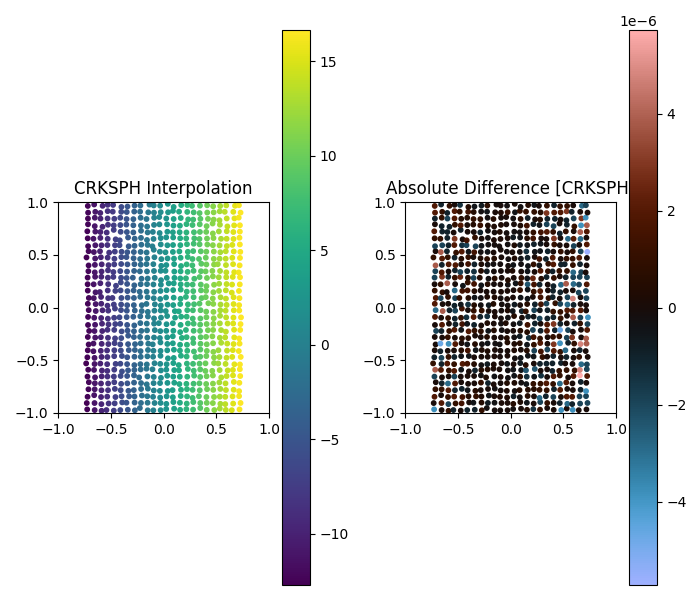

In [22]:
mask = torch.logical_and(referencePositions[:,0] > -0.75, referencePositions[:,0] < 0.75)

fig, axis = plt.subplots(1, 2, figsize = (7,6), squeeze=False)

c = axis[0,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = warp_interpolation_crk[mask].cpu(), s = 10)
axis[0,0].set_title("CRKSPH Interpolation")
fig.colorbar(c, ax = axis[0,0])

diff = (warp_interpolation_crk - f)
c = axis[0,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff[mask].cpu(), s = 10, cmap = 'berlin')
axis[0,1].set_title("Absolute Difference [CRKSPH]")
fig.colorbar(c, ax = axis[0,1])

for a in axis.flatten():
    a.set_aspect('equal')
    a.set_xlim(domain.min[0].item(), domain.max[0].item())
    a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [23]:

def correctedGradientKernel(A, B, gradA, gradB, kernelValues, supportScheme: SupportScheme = SupportScheme.SuperSymmetric, xji: bool = False):
    fac = -1 if xji else 1
    W_ij = evalKernel(kernelValues, supportScheme=supportScheme, combined=True)
    gradW_ij = evalKernelGradient(kernelValues, supportScheme=supportScheme, combined=True)
    
    dotProd = lambda a, b: torch.einsum('...i, ...j -> ...', a, b)
    dot_ii = lambda a, b: torch.einsum('...i, ...i -> ...', a, b)
    
    # term 1 :A B^k W_ab
    # term 2: A (1 + B^i x_ij^i) gradW
    # term 3: (1 + B^i x_ij^i) W (partial_k A)
    # term 4: A (x_ij^i partial_k B^i) W

    x_ij = kernelValues.x_ij
    # if xji:
        # x_ij = -x_ij

    term1 = A.view(-1,1) * B * W_ij.view(-1,1)
    term2 = fac * (A * (1 + fac * dot_ii(B, x_ij))).view(-1,1) * gradW_ij
    term3 = (1 + fac * dot_ii(B, x_ij)).view(-1,1) * W_ij.view(-1,1) * gradA
    term4 = fac * A.view(-1,1) * (torch.einsum('...a,...ca -> ...c', x_ij, gradB)) * W_ij.view(-1,1)

    # print(f'GradW_ij: {gradW_ij.shape}, A: {A.shape}, B: {B.shape}, kernelValues.x_ij: {kernelValues.x_ij.shape}')
    # print(f'Term1: {term1}')
    # print(f'Term2: {term2}')
    # print(f'Term3: {term3}')
    # print(f'Term4: {term4}')
    
    # print(f'term1: min {term1.min()}, max {term1.max()}, mean {term1.mean()}')
    # print(f'term2: min {term2.min()}, max {term2.max()}, mean {term2.mean()}')
    # print(f'term3: min {term3.min()}, max {term3.max()}, mean {term3.mean()}')
    # print(f'term4: min {term4.min()}, max {term4.max()}, mean {term4.mean()}')
    
    summed = term1 + term2 + term3 + term4
    # print(f'summed: min {summed.min()}, max {summed.max()}, mean {summed.mean()}')
    
    # print(f'gradW_ij: min {gradW_ij.min()}, max {gradW_ij.max()}, mean {gradW_ij.mean()}')

    return term1 + term2 + term3 + term4

# print(f'A: {A.shape}, B: {B.shape}, kernelValues: {neighborhood[1].x_ij.shape}')

# corr =correctedKernel(simulationState.A[adjacency.i], simulationState.B[adjacency.i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)
# print(corr.shape)
# print(corr[adjacency.edgeOffsets[128]].cpu().numpy().item())

# corrGrad = correctedGradientKernel(simulationState.A[adjacency.i], simulationState.B[adjacency.i], simulationState.gradA[adjacency.i], simulationState.gradB[adjacency.i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)
# print(corrGrad.shape)
# print(corrGrad[adjacency.edgeOffsets[128]].cpu().numpy())

In [24]:
# grad_W_ij[adjacency.edgeOffsets[128]].cpu().numpy() - res[:2]

In [25]:
j = neighborhood[0].col
i = neighborhood[0].row

fj = f[j]
Vj = simulationState.apparentArea[j]

grad_W_ij = correctedGradientKernel(simulationState.A[i], simulationState.B[i], simulationState.gradA[i], simulationState.gradB[i], neighborhood[1], supportScheme=DiffSPHSupportScheme.SuperSymmetric)

Term = (Vj  * fj).view(-1,1) * grad_W_ij
result = scatter_sum(Term, i, dim = 0, dim_size = simulationState.positions.shape[0])

In [26]:
import warp as wp
from warp.types import vector, matrix
# from wp_tensor import tensor
from typing import Any
import torch
from sphWarpCore.utils.wp_autograd import *
from sphWarpCore.radiusSearch.radius_util import convertModeToUint

from sphWarpCore.radiusSearch.radius_util import AdjacencyList, AdjacencyListWarp, DomainDescription, PointCloud
from sphWarpCore.mathutil.wp_math import *
from sphWarpCore.kernels.wp_kernel import *
from sphWarpCore.utils.wp_util import getCachedDummyTensor, checkDirectionality_i, checkDirectionality_j
from torch.profiler import profile, record_function, ProfilerActivity

# For matrices we need to implement the logic manually using outer products, since Warp does not support rank-2 field types natively. The output is stored as a flattened vector and reshaped on the Python side.
@wp.func
def computeSPHGradientTensor_Func(
    i : wp.int32,
    xi: vector(dtype = wp.float32, length=Any), hi : wp.float32, mi: wp.float32, rhoi: wp.float32, fi : vector(dtype = wp.float32, length=Any), # type: ignore
    
    positions : wp.array(dtype=vector(length=Any, dtype = wp.float32)), supports : wp.array(dtype = wp.float32), masses: wp.array(dtype = wp.float32), densities: wp.array(dtype = wp.float32), values: wp.array(dtype = vector(dtype = wp.float32, length=Any)), # type: ignore
    
    periodicity : wp.array(dtype = wp.bool), domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), # type: ignore
    mode_uint: wp.uint32, kernel_int: wp.int32, gradientMode_int: wp.int32, # type: ignore
    
    neighborList: wp.array(dtype = wp.int64), # type: ignore
    neighborOffset : wp.int32, numNeighs: wp.int32, preScatteredQuantities: wp. bool,
    
    numDims: wp.int32, flatInputShape: wp.int32, flatOutputShape: wp.int32,
    L: wp.array(dtype = matrix(shape=(Any, Any), dtype=wp.float32)), renormalize: wp.bool, # type: ignore
    referenceOmegas: wp.array(dtype = wp.float32), gradHTerms: wp.bool, # type: ignore
    opInt: wp.int32, referenceKinds : wp.array(dtype = wp.int32), # type: ignore

    useVolume: bool, referenceVolumes: wp.array(dtype = wp.float32), # type: ignore
    useCRK: bool, Ai: wp.float32, Bi: vector(length=Any, dtype=wp.float32), gradA_i: vector(length=Any, dtype=wp.float32), gradB_i: matrix(shape=(Any, Any), dtype=wp.float32), # type: ignore
    
    outputValue: vector(length=Any, dtype=wp.float32) # type: ignore
):
    dim = wp.int32(xi.length)
    grad_f_interpolated = type(outputValue)(0.0)

    Li = type(L[0])()
    if renormalize:
        Li = L[i]
    
    for neighborIndex in range(numNeighs):
        jj = neighborOffset + neighborIndex
        j = wp.int32(neighborList[jj])
        if opInt != 0:
            if not checkDirectionality_j(referenceKinds[j], opInt):
                continue
        
        mj = masses[j]
        rhoj = densities[j]
        apparentVolume = mj / rhoj if not useVolume else referenceVolumes[j]
        fj = type(fi)(0.0)
        if preScatteredQuantities:
            if gradHTerms:
                fj = values[jj] / referenceOmegas[j]
            else:
                fj = values[jj]
        else:
            if gradHTerms:
                fj = values[j] / referenceOmegas[j]
            else:
                fj = values[j]
                
        x_ij = computeDistanceVec(xi, positions[j], periodicity, domainMin, domainMax)
        kernelGradient = sphKernelGradient_ij(x_ij, hi, supports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)

        if useCRK:
            W_ij = sphKernel_ij(x_ij, hi, supports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)
            kernelGradient = correctGradientCRK(
                W_ij,
                kernelGradient, 
                x_ij, 
                Ai, Bi, gradA_i, gradB_i, 
                get_dim(xi))

        if renormalize:
            kernelGradient = matmul(Li, kernelGradient)
        

        if gradientMode_int == 1: # Naive
            grad_f_interpolated += outerTensorProduct(fj * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)
        elif gradientMode_int == 2: # Symmetric
            grad_f_interpolated += outerTensorProduct(mj * rhoi * (fi / iPow(rhoi,2) + fj / iPow(rhoj,2)) * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)
        elif gradientMode_int == 3: # Difference
            grad_f_interpolated += outerTensorProduct((fj - fi) * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)
        elif gradientMode_int == 4: # Summation
            grad_f_interpolated += outerTensorProduct((fj + fi) * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)
            
    return grad_f_interpolated


In [27]:

@wp.kernel
def computeSPHGradientTensor_Kernel(
    queryPositions : wp.array(dtype = vector(length=Any, dtype=wp.float32)), referencePositions : wp.array(dtype=vector(length=Any, dtype=wp.float32)), # type: ignore
    querySupports : wp.array(dtype = wp.float32), referenceSupports : wp.array(dtype = wp.float32), # type: ignore
    queryMasses: wp.array(dtype = wp.float32), referenceMasses: wp.array(dtype = wp.float32),  # type: ignore
    queryDensities: wp.array(dtype = wp.float32), referenceDensities: wp.array(dtype = wp.float32), # type: ignore
    queryValues: wp.array(dtype =vector(dtype = wp.float32, length=Any)), referenceValues: wp.array(dtype = vector(dtype = wp.float32, length=Any)), # type: ignore
    
    domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), periodicity : wp.array(dtype = wp.bool), # type: ignore
    
    mode_uint: wp.uint32, kernel_int : wp.int32, gradientMode_int: wp.int32,
    neighborList: wp.array(dtype = wp.int64), neighborListRowOffsets: wp.array(dtype = wp.int32), numNeighbors: wp.array(dtype = wp.int32), preScatteredQuantities: wp. bool,# type: ignore
    
    numDims: wp.int32, flatInputShape: wp.int32, flatOutputShape: wp.int32,
    L: wp.array(dtype = matrix(shape=(Any, Any), dtype=wp.float32)), renormalize: wp.bool, # type: ignore
    queryOmegas: wp.array(dtype = wp.float32), referenceOmegas: wp.array(dtype = wp.float32), gradHTerms: wp.bool, # type: ignore
    opInt: wp.int32, queryKinds : wp.array(dtype = wp.int32), referenceKinds : wp.array(dtype = wp.int32), # type: ignore

    useVolume: bool, queryVolumes: wp.array(dtype = wp.float32), referenceVolumes: wp.array(dtype = wp.float32), # type: ignore
    useCRK: bool, crk_A: wp.array(dtype = wp.float32), crk_B: wp.array(dtype = vector(length=Any, dtype=wp.float32)), crk_gradA: wp.array(dtype = vector(length=Any, dtype=wp.float32)), crk_gradB: wp.array(dtype = matrix(shape=(Any, Any), dtype=wp.float32)), # type: ignore
    
    outputValues : wp.array(dtype = vector(length=Any, dtype = wp.float32)) # type: ignore
):                                                                                    
    i = wp.tid()
    if i >= queryPositions.shape[0]:
        return
    if opInt != 0:
        if not checkDirectionality_i(queryKinds[i], opInt):
            return
    
    xi = queryPositions[i]
    hi = querySupports[i]
    mi = queryMasses[i]
    rhoi = queryDensities[i]
    fi = queryValues[i]
    if gradHTerms:
        fi = queryValues[i] / queryOmegas[i]

    Ai = crk_A[i] if useCRK else type(crk_A[0])(0.0)
    Bi = crk_B[i] if useCRK else type(crk_B[0])(0.0)
    gradA_i = crk_gradA[i] if useCRK else type(crk_gradA[0])(0.0)
    gradB_i = crk_gradB[i] if useCRK else type(crk_gradB[0])()*0.0
    
    outputValues[i] = computeSPHGradientTensor_Func(
        i,
        xi, hi, mi, rhoi, fi, 
        referencePositions, referenceSupports, referenceMasses, referenceDensities, referenceValues,
        
        periodicity, domainMin, domainMax, 
        mode_uint, kernel_int, gradientMode_int,
        neighborList, neighborListRowOffsets[i], numNeighbors[i], 
        preScatteredQuantities,
        numDims, flatInputShape, flatOutputShape,
        L, renormalize,
        referenceOmegas, gradHTerms,
        opInt, referenceKinds,
        useVolume, referenceVolumes,
        useCRK, Ai, Bi, gradA_i, gradB_i,
        type(outputValues[i])(0.0))
    


from sphWarpCore.enumTypes import *
from typing import Optional

def computeSPHGradient_warpBackend(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    queryValues : Optional[torch.Tensor], referenceValues : Optional[torch.Tensor],
    queryKinds, referenceKinds,
    domain: DomainDescription,
    mode: SupportScheme,
    kernel: KernelFunctions,    
    gradientMode: GradientScheme,
    operationMode: OperationDirection,
    adjacency: AdjacencyListWarp,
    scatteredQuantities: Optional[torch.Tensor] = None,
    useGradientRenormalization: bool = False, renormalizationMatrices: Optional[torch.Tensor] = None,
    gradH_corrections: bool = False, queryOmegas: Optional[torch.Tensor] = None, referenceOmegas: Optional[torch.Tensor] = None,
    useVolume: bool = False, queryVolumes: Optional[torch.Tensor] = None, referenceVolumes: Optional[torch.Tensor] = None,
    useCRK: bool = False, crk_A: Optional[torch.Tensor] = None, crk_B: Optional[torch.Tensor] = None, crk_gradA: Optional[torch.Tensor] = None, crk_gradB: Optional[torch.Tensor] = None
):
    with record_function("warpSPH[Gradient]"):
        with record_function("warpSPH[Gradient] - Preprocessing"):
            domainMin = domain.min
            domainMax = domain.max
            periodicity = domain.periodic

            mode_uint = supportSchemeToUint(mode)
            kernel_int = kernel.value
            gradientMode_int = gradientMode.value
            opInt = wp.int32(operationMode.value)

            preScatteredQuantities = False # Indicates if the input quantities have already been scattered to the neighbor level (e.g. mass/density products), which can save some redundant computations if they are needed for multiple operations. This can also help with some custom kernels where we want to pre-compute certain quantities at the neighbor level on the Python side and pass them in as additional fields to avoid redundant computations in the kernel. 
            if queryValues is None and referenceValues is None:
                if scatteredQuantities is None:
                    raise ValueError("If queryValues and referenceValues are not provided, then pre-scattered quantities must be provided for the gradient computation.")
                preScatteredQuantities = True
                qV = scatteredQuantities
                rV = scatteredQuantities
            else:
                qV = queryValues
                rV = referenceValues

            # Warp kernels only support rank-1 (vector) and rank-2 (matrix) field types.
            outputSize = (queryPositions.shape[0])

            inputShape = qV.shape[1:]
            flatInputShape = 1
            for dim in inputShape:
                flatInputShape *= dim

            outputShape = inputShape + (queryPositions.shape[1],) # add an extra dimension for the gradient
            flatOutputShape = 1
            for dim in outputShape:
                flatOutputShape *= dim
            # Warp kernels only support rank-1 (vector) and rank-2 (matrix) field types.
            numDims = len(inputShape)

            D = queryPositions.shape[1]
            L = renormalizationMatrices if renormalizationMatrices is not None else getCachedDummyTensor((1, D, D), dtype=torch.float32, device=queryPositions.device)
            renormalize = useGradientRenormalization

            Oi = queryOmegas if queryOmegas is not None else getCachedDummyTensor((queryPositions.shape[0],), dtype=torch.float32, device=queryPositions.device)
            Oj = referenceOmegas if referenceOmegas is not None else getCachedDummyTensor((referencePositions.shape[0],), dtype=torch.float32, device=queryPositions.device)
            gradHTerms = gradH_corrections
        with record_function("warpSPH[Gradient] - Kernel Execution"):
            warp_result = warpWrapper(
                launch_kernel, computeSPHGradientTensor_Kernel, outputSize, vector(length=flatOutputShape, dtype = wp.float32),
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                qV.view(-1, flatInputShape), rV.view(-1, flatInputShape),
                domainMin, domainMax, periodicity,
                mode_uint, kernel_int, gradientMode_int,
                adjacency.j, adjacency.edgeOffsets, adjacency.numNeighbors, preScatteredQuantities,
                wp.int32(numDims), wp.int32(flatInputShape), wp.int32(flatOutputShape),
                L, wp.bool(renormalize), 
                Oi, Oj, wp.bool(gradHTerms),
                opInt, queryKinds, referenceKinds,
                wp.bool(useVolume), queryVolumes, referenceVolumes,
                wp.bool(useCRK), crk_A, crk_B, crk_gradA, crk_gradB
            )

    return warp_result.view(queryPositions.shape[0], *outputShape) # reshape back to original shape with new gradient dimension

In [28]:
# f_grad_crk_warp = computeSPHGradient_warpBackend(
#     queryPositions, referencePositions,
#     querySupports, referenceSupports,
#     queryMasses, referenceMasses,
#     queryDensities, referenceDensities,
#     f, f,
#     torch.zeros(size = (queryPositions.shape[0],), device=queryPositions.device, dtype = torch.int32), torch.zeros(size = (referencePositions.shape[0],), device=referencePositions.device, dtype = torch.int32),
#     domain,
#     mode = SupportScheme.SuperSymmetric, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Naive, operationMode = OperationDirection.AllToAll,
#     adjacency = adjacency,
#     useGradientRenormalization = False, renormalizationMatrices = None,
#     gradH_corrections = False, queryOmegas = None, referenceOmegas = None,
#     useVolume = True, queryVolumes = simulationState.apparentArea, referenceVolumes = simulationState.apparentArea,
#     useCRK = True, crk_A = simulationState.A, crk_B = simulationState.B, crk_gradA = simulationState.gradA, crk_gradB = simulationState.gradB
# )   


f_grad_crk_warp = sphOperation_warp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    f, f,
    domain, 
    operation = WarpOperation.Gradient,
    gradientMode = GradientScheme.Naive,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.SuperSymmetric,
    operationMode = OperationDirection.AllToAll, 
    adjacency = adjacency,
    useCRK=True, crk_A = simulationState.A, crk_B = simulationState.B, crk_gradA=simulationState.gradA, crk_gradB=simulationState.gradB,
    useVolume=True, queryVolumes=simulationState.apparentArea, referenceVolumes=simulationState.apparentArea
)

[Kernel.add_overload] Creating new overload for computeSPHGradientTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v1f4_a1v1f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i4_a1i4_b_i4_i4_i4_i4_a1i4_a1i4_b_a1m22f4_b_a1f4_a1f4_b_a1f4_a1f4_b_a1f4_a1v2f4_a1v2f4_a1m22f4_a1v2f4
Module sphWarpCore.operations.wp_gradient e8953a0 load on device 'cuda:0' (block_dim=256) ...
            out += outerTensorProduct((fj + fi) * apparentVolume, kernelGradient, out, numDims, flatInputShape, flatOutputShape)

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp___main___63bdc91.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-nu

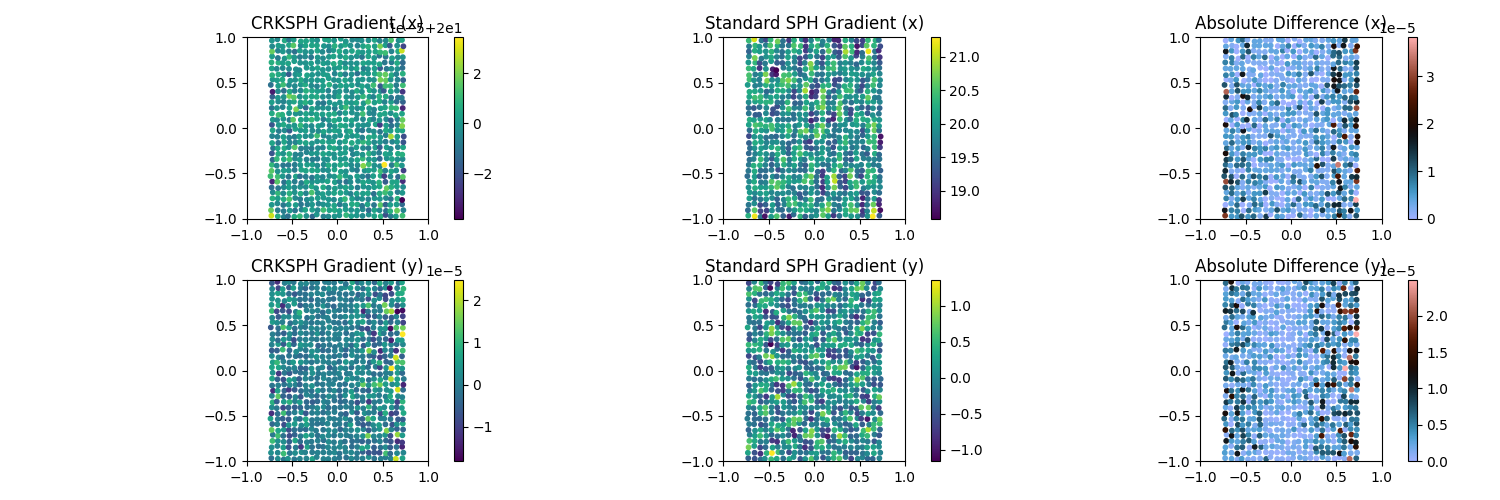

In [30]:
f_grad_crk = SPHOperation(
    simulationState,
    quantity = f,
    kernel = KernelType.Wendland2,
    neighborhood = neighborhood[0],
    kernelValues = neighborhood[1],
    operation= Operation.Gradient,
    supportScheme = DiffSPHSupportScheme.Gather,
    gradientMode = GradientMode.Naive,
    correctionTerms= [KernelCorrectionScheme.CRKSPH],
    positiveDivergence=False,
    useApparentArea=True
)
f_grad = SPHOperation(
    simulationState,
    quantity = f,
    kernel = KernelType.Wendland2,
    neighborhood = neighborhood[0],
    kernelValues = neighborhood[1],
    operation= Operation.Gradient,
    supportScheme = DiffSPHSupportScheme.Gather,
    gradientMode = GradientMode.Difference,
    correctionTerms= [],
    positiveDivergence=False
)

x_grad_analytic = 20 * torch.ones_like(f_grad[:,0])
y_grad_analytic = torch.zeros_like(f_grad[:,1])

mask = torch.logical_and(referencePositions[:,0] > -0.75, referencePositions[:,0] < 0.75)
fig, axis = plt.subplots(2,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_grad_crk_warp[mask,0].cpu(), s = 10)
axis[0,0].set_title("CRKSPH Gradient (x)")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_grad[mask,0].cpu(), s = 10)
axis[0,1].set_title("Standard SPH Gradient (x)")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_grad_crk_warp[mask,0] - x_grad_analytic[mask])
c = axis[0,2].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference (x)")
fig.colorbar(c, ax = axis[0,2])

c = axis[1,0].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_grad_crk_warp[mask,1].cpu(), s = 10)
axis[1,0].set_title("CRKSPH Gradient (y)")
fig.colorbar(c, ax = axis[1,0])

c = axis[1,1].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = f_grad[mask,1].cpu(), s = 10)
axis[1,1].set_title("Standard SPH Gradient (y)")
fig.colorbar(c, ax = axis[1,1])

diff = torch.abs(f_grad_crk_warp[mask,1] - y_grad_analytic[mask])
c = axis[1,2].scatter(referencePositions[mask,0].cpu(), referencePositions[mask,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')    
axis[1,2].set_title("Absolute Difference (y)")
fig.colorbar(c, ax = axis[1,2])

for a in axis.flatten():
    a.set_aspect('equal')
    a.set_xlim(domain.min[0].item(), domain.max[0].item())
    a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f = torch.randn_like(referenceDensities)

fig, axis = plt.subplots(1,1, figsize = (7,5), squeeze=False)

axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f.cpu(), s = 10, cmap = 'berlin')
axis[0,0].set_title("Random Field f")
fig.colorbar(c, ax = axis[0,0])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()


In [ ]:
f_interpolated_warp = sphOperation_warp(
        queryPositions, referencePositions, 
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain, adjacency,
        operation=WarpOperation.Interpolate,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather
)

f_interpolated_diffSPH = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
)

fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_interpolated_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Interpolation")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_interpolated_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Interpolation")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_interpolated_warp - f_interpolated_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
)
f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        None, None,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Naive,
        preScatteredQuantities=f_interpolated_warp[adjacency.j] - f_interpolated_warp[adjacency.i]
)

f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
)

fig, axis = plt.subplots(2,3, figsize = (12,7), squeeze=False, sharex=True, sharey=True)

for d in range(2):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_gradient_warp - f_gradient_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
from sphWarpCore.operations.wp_covariance import computeSPHCovariance_warpBackend
from diffSPH.math import pinv2x2

C = computeSPHCovariance_warpBackend(
    queryPositions, referencePositions, 
    querySupports, referenceSupports, 
    queryMasses, referenceMasses, 
    queryDensities, referenceDensities, 
    domain = domain, adjacency = adjacency, 
    mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, renormalizationMatrices = None)

num_nbrs = adjacency.numNeighbors
dtype = C.dtype

C[num_nbrs < 4,:,:] = torch.eye(dim, dtype = dtype, device = device)[None,:,:]

if queryPositions.shape[1] == 2:
    L, eigVals = pinv2x2(C)
else:
    L = torch.linalg.pinv(C)
    eigVals = torch.linalg.eigvals(C).real

    if queryPositions.shape[1] == 3:
        eigVals[torch.abs(eigVals[:,1]) > torch.abs(eigVals[:,0]),:] = torch.flip(eigVals[torch.abs(eigVals[:,1]) > torch.abs(eigVals[:,0]),:],[1])
        eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,1]),:] = torch.flip(eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,1]),:],[1])
        eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,0]),:] = torch.flip(eigVals[torch.abs(eigVals[:,2]) > torch.abs(eigVals[:,0]),:],[1])


In [ ]:
C

In [ ]:
from diffSPH.modules.renorm import computeCovarianceMatrices

simulationState.numNeighbors = adjacency.numNeighbors

C_diffSPH, L, eigVals = computeCovarianceMatrices(
    simulationState,
    neighborhood = neighborhood,
    kernel = KernelType.Wendland2,
    supportScheme = SupportScheme.Gather
)
C_diffSPH

In [ ]:
(C_diffSPH - C).max()

In [ ]:

f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference,
        renormalizationMatrices=L
)

from diffSPH.operations import KernelCorrectionScheme

simulationState.gradCorrectionMatrices = L
f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= [KernelCorrectionScheme.gradientRenorm]
)

fig, axis = plt.subplots(2,3, figsize = (12,7), squeeze=False, sharex=True, sharey=True)

for d in range(2):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_gradient_warp - f_gradient_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:

from diffSPH.modules.adaptiveSmoothing import *

omega = computeOmega(simulationState, KernelType.Wendland2, neighborhood, SupportScheme.Gather, {})

print(omega)
simulationState.omega = omega

In [ ]:
f_gradient_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Gradient,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference,
        # renormalizationMatrices=L,
        queryOmegas=omega, referenceOmegas=omega,
)

from diffSPH.operations import KernelCorrectionScheme

simulationState.gradCorrectionMatrices = L
f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= [KernelCorrectionScheme.gradH]
)

fig, axis = plt.subplots(2,3, figsize = (12,7), squeeze=False, sharex=True, sharey=True)

for d in range(2):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Gradient - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_gradient_warp - f_gradient_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:

f_vec = torch.zeros_like(referencePositions)

u_mag = 1

k_ = 2

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

f_vec[:,0] =  u_mag * torch.cos(ktgv * np.pi * referencePositions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * referencePositions[:,1] + phaseShift_y)
f_vec[:,1] = -u_mag * torch.sin(ktgv * np.pi * referencePositions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * referencePositions[:,1] + phaseShift_y)

fig, axis = plt.subplots(1,2, figsize = (10,4), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_vec[:,0].cpu(), s = 10, cmap = 'berlin')
axis[0,0].set_title("Vector Field f - Dim 0")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_vec[:,1].cpu(), s = 10, cmap = 'berlin')
axis[0,1].set_title("Vector Field f - Dim 1")
fig.colorbar(c, ax = axis[0,1])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_divergence_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_vec, f_vec,
        domain, adjacency,
        operation=WarpOperation.Divergence,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
)

f_gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_vec,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Divergence,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
)

fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_divergence_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Divergence")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_gradient_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Divergence")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_divergence_warp - f_gradient_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_curl_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_vec, f_vec,
        domain, adjacency,
        operation=WarpOperation.Curl,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode = GradientScheme.Difference
)

f_curl_diffSPH = SPHOperation(
        simulationState,
        quantity = f_vec,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Curl,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
)

fig, axis = plt.subplots(1,3, figsize = (12,4), squeeze=False, sharex=True, sharey=True)

for d in range(1):
    c = axis[d,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_curl_warp[:,d].cpu(), s = 10)
    axis[d,0].set_title(f"WarpSPH Curl - Dim {d}")
    fig.colorbar(c, ax = axis[d,0])

    c = axis[d,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_curl_diffSPH[:,d].cpu(), s = 10)
    axis[d,1].set_title(f"diffSPH Curl - Dim {d}")
    fig.colorbar(c, ax = axis[d,1])

    diff = torch.abs(f_curl_warp - f_curl_diffSPH)
    c = axis[d,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff[:,d].cpu(), s = 10, cmap = 'berlin')
    axis[d,2].set_title(f"Absolute Difference - Dim {d}")
    fig.colorbar(c, ax = axis[d,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [ ]:
f_scalar_laplacian_warp = sphOperation_warp(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_interpolated_warp, f_interpolated_warp,
        domain, adjacency,
        operation=WarpOperation.Laplacian,
        kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
        gradientMode= GradientScheme.Difference,
        laplacianMode = LaplacianMode.Brookshaw
)

f_scalar_laplacian_diffSPH = SPHOperation(
        simulationState,
        quantity = f_interpolated_warp,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1], 
        operation=Operation.Laplacian,
        supportScheme = SupportScheme.Gather,
        gradientMode= GradientMode.Difference,
        laplacianMode = LaplacianMode.Brookshaw
)

fig, axis = plt.subplots(1,3, figsize = (15,5), squeeze=False)

c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_scalar_laplacian_warp.cpu(), s = 10)
axis[0,0].set_title("WarpSPH Laplacian")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = f_scalar_laplacian_diffSPH.cpu(), s = 10)
axis[0,1].set_title("diffSPH Laplacian")
fig.colorbar(c, ax = axis[0,1])

diff = torch.abs(f_scalar_laplacian_warp - f_scalar_laplacian_diffSPH)
c = axis[0,2].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = diff.cpu(), s = 10, cmap = 'berlin')
axis[0,2].set_title("Absolute Difference")
fig.colorbar(c, ax = axis[0,2])

for a in axis.flatten():
        a.set_aspect('equal')
        a.set_xlim(domain.min[0].item(), domain.max[0].item())
        a.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()
